## Visualizing Low cost Data

In [1]:
import os
import pathlib
import random
import ast
from abc import ABC, abstractmethod

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from utils.load_fns import load_data, plot_spectral
from typing import Optional



data_path = './spectrometry'

## Dataset Abstraction

In [2]:
class Dataset(ABC):

    @abstractmethod
    def __len__(self):
        raise NotImplementedError('Child must implemented len method')
    @abstractmethod
    def __getitem__(self):
        raise NotImplementedError('Child must implement getitem method')

if __name__ == '__main__':
    try:
        dataset = Dataset()
        assert False, f'Cannot create from abstract class'
    except Exception as e:
        pass
    print('Test passed')

Test passed


## Low Cost Dataset Object

Test passed


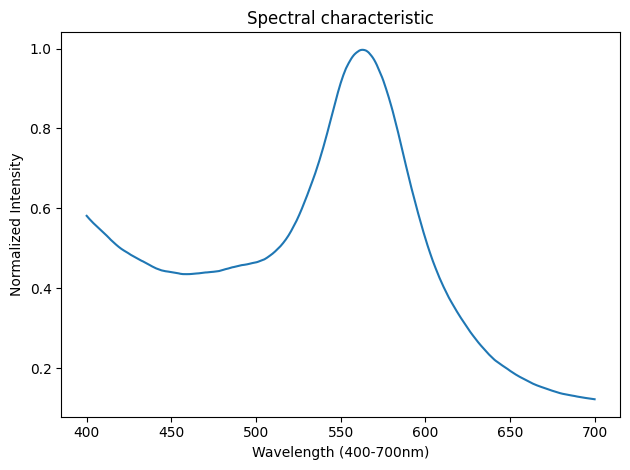

In [3]:
class Spectral_Dataset(Dataset):

    def __init__(self, data_url):
        self.spectral_urls = []
        self.image_urls = []
        load_data(data_url, self.spectral_urls, self.image_urls)
        assert len(self.spectral_urls) == len(self.image_urls), f'Incosistent data size detected'

    def __len__(self):
        return len(self.spectral_urls)

    def clean_cols(self, df, index):
        df_cols = df.columns
        target_cols = ['spectral_1', 'spectral_2', 'calibration']
        if 'wavelength' in df_cols:
            target_cols.extend(['wavelength'])
            
        extracted_vals = []
        for col in target_cols:
            data_v = ast.literal_eval(df[col][0])
            if isinstance(data_v, dict):
                data_v = data_v['intensity']
            data_v = np.array(data_v)
            extracted_vals.append(data_v)
        avg_spectral = (extracted_vals[0] + extracted_vals[1]) / 2
        wavelength = extracted_vals[-1] if 'wavelength' in target_cols else None
        return wavelength, avg_spectral
                

    def __getitem__(self, index):
        spectral_url, img_url = self.spectral_urls[index], self.image_urls[index]
        specimen_df = pd.read_csv(spectral_url)
        specimen_df = self.clean_cols(specimen_df, index)
        return specimen_df[0], specimen_df[-1], img_url

    def get_meta_data(self, index):
        pass

if __name__ == "__main__":
    dataset = Spectral_Dataset(data_path)
    INDEX = 400
    wavelength, data, img_url = dataset[INDEX]
    print('Test passed')


plot_spectral(wavelength, data)

## Data Loader

In [4]:
class Dataloader:

    @abstractmethod
    def __iter__(self):
        raise NotImplementedError('Child classes must implemented this method')
        

class Spectral_Dataloader(Dataloader):

    def __init__(self, dataset: Dataset, batch_size:int, _random: Optional[bool]= False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.random = _random
        self.indices = None

    def __iter__(self):
        _len = len(self.dataset)
        indices = np.arange(_len)
        if self.random:
            random.shuffle(indices)
        self.indices = indices
        
        for i in range(0, _len, self.batch_size):
            selected = indices[i: i + self.batch_size]
            extracted_data = []
            for index in selected:
                _, data, _ = self.dataset[index]
                if data is None:
                    continue
                extracted_data.append(data)
            yield make_contiguous(extracted_data)
            
            

def make_contiguous(temp_data):
    _size = len(temp_data)
    assert _size > 0, f'Empty list parsed'
    _shape= temp_data[0].shape
    buffer = np.zeros((_size, _shape[0]))
    for i, data_v in enumerate(temp_data):
        buffer[i, :] = data_v
    return buffer

if __name__ == "__main__":
    dataset = Spectral_Dataset(data_path)
    dataloader = Spectral_Dataloader(dataset, 10,  True)
    x_train = next(iter(dataloader))

x_train.shape

(10, 381)

## Running Multiple Tests

In [20]:
pca_tests = [20, 40, 50, 60, 80, 100, 120, 140]

def run_tests():
    test_state_obj = {}
    dataset = Spectral_Dataset(data_path)
    dataloader = Spectral_Dataloader(dataset, len(dataset), True)
    x  = next(iter(dataloader))


    for pca_components in pca_tests:
        pca = PCA(n_components= pca_components)
        x_pca = pca.fit_transform(x)

        kmeans = KMeans(n_clusters=3, random_state=42)
        kmeans.fit(x_pca)
        labels = kmeans.labels_
        centers = kmeans.cluster_centers_
        temp  = {}
        temp['labels'] = labels
        temp['centers'] = centers
        test_state_obj[pca_components] = temp

    # visualize components
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x)
    return test_state_obj, x_pca

if __name__ == "__main__":
    state_ob, x_pca = run_tests()

## Visualization of Test Results

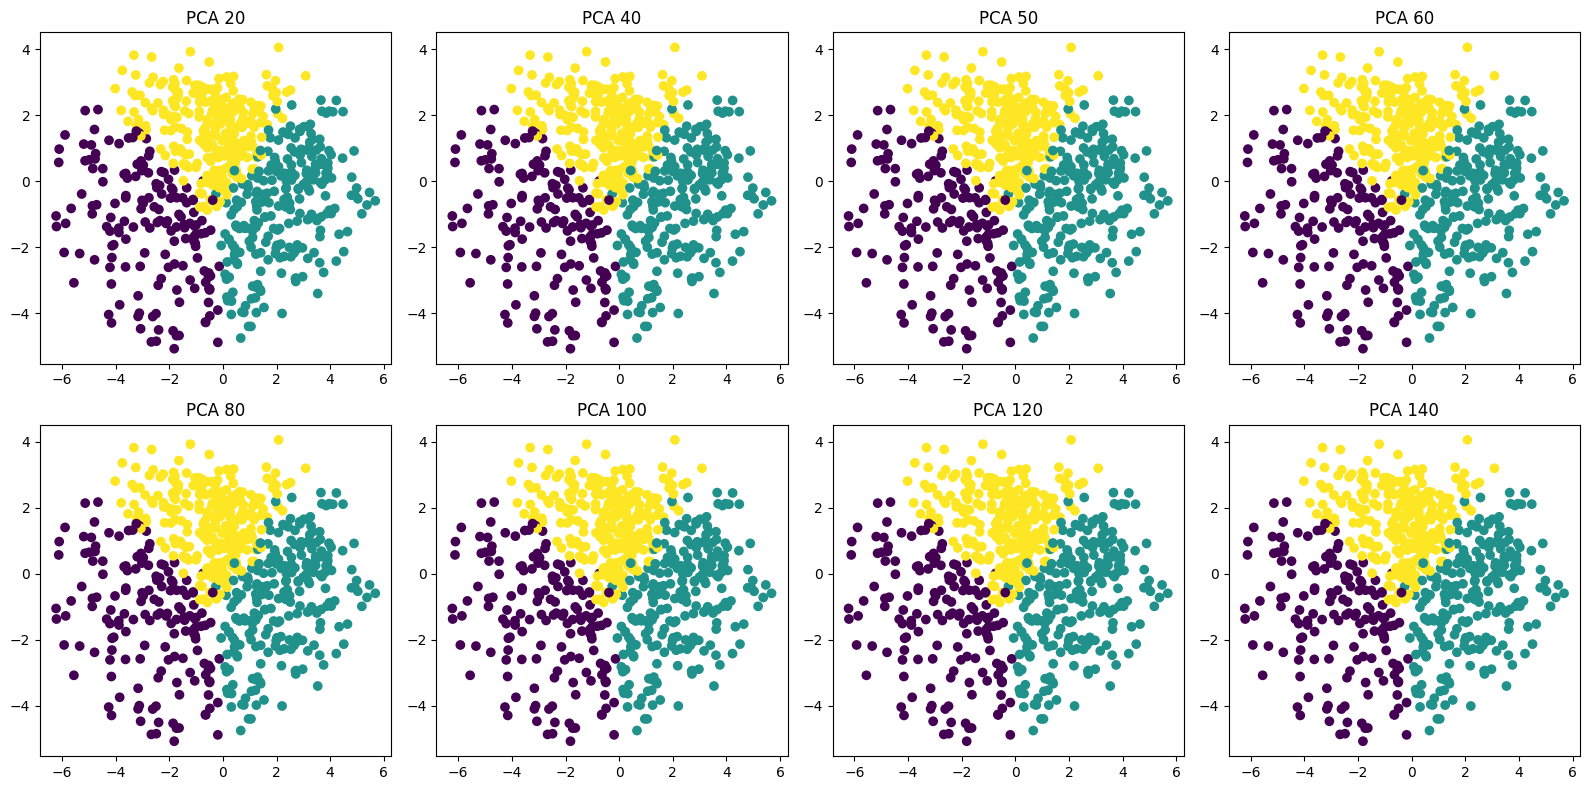

In [22]:
def visualize(x_pca, state_obj):
    fig, axes = plt.subplots(2, 4, figsize= (16, 8))
    axes = axes.flatten()
    for i, key in enumerate(state_obj.keys()):
        axes[i].scatter(x_pca[:, 0], x_pca[:, 1], c=state_obj[key]['labels'])
        axes[i].set_title(f'PCA {key}')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize(x_pca, state_ob)